# Exploratory Data Analysis: Binance Daily Market Prices

This notebook validates the raw daily OHLCV extracts for **BTCUSDT**, **ETHUSDT**, **LINKUSDT**, and **UNIUSDT** under two actuarial valuation windows:

- **Baseline scenario:** window ending 15 March 2024 (`data/01_raw/baseline_mar2024/`)
- **Stress scenario:** window ending 5 August 2024 (`data/01_raw/stress_aug2024/`)

Each series is expected to contain approximately **731** daily observations (`days_back=730` inclusive of the end date). The key visual check is whether the close-price paths are continuous, correctly aligned in calendar time, and consistent with the intended market regimes across all four assets.

## 1. Imports and configuration

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 8),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": True,
        "axes.spines.top": False,
    }
)

EXPECTED_ROWS = 731
CLOSE_COL = "close"

## 2. Data loading

CSV paths are resolved relative to this notebook (`notebooks/`), using `../data/01_raw/...`. The `date` column is parsed as datetime and set as the index. Eight extracts are loaded: BTC, ETH, LINK, and UNI for both the baseline and stress folders.

In [3]:
RAW_DATA_DIR = Path("../data/01_raw")
BASELINE_DIR = RAW_DATA_DIR / "baseline_mar2024"
STRESS_DIR = RAW_DATA_DIR / "stress_aug2024"


def load_price_series(csv_path: Path) -> pd.DataFrame:
    """Load a Binance daily extract and index it by calendar date."""
    frame = pd.read_csv(csv_path, parse_dates=["date"])
    return frame.set_index("date").sort_index()


btc_baseline = load_price_series(BASELINE_DIR / "binance_prices_btc.csv")
eth_baseline = load_price_series(BASELINE_DIR / "binance_prices_eth.csv")
link_baseline = load_price_series(BASELINE_DIR / "binance_prices_link.csv")
uni_baseline = load_price_series(BASELINE_DIR / "binance_prices_uni.csv")
btc_stress = load_price_series(STRESS_DIR / "binance_prices_btc.csv")
eth_stress = load_price_series(STRESS_DIR / "binance_prices_eth.csv")
link_stress = load_price_series(STRESS_DIR / "binance_prices_link.csv")
uni_stress = load_price_series(STRESS_DIR / "binance_prices_uni.csv")

series_catalog = {
    "BTC baseline (Mar 2024)": btc_baseline,
    "ETH baseline (Mar 2024)": eth_baseline,
    "LINK baseline (Mar 2024)": link_baseline,
    "UNI baseline (Mar 2024)": uni_baseline,
    "BTC stress (Aug 2024)": btc_stress,
    "ETH stress (Aug 2024)": eth_stress,
    "LINK stress (Aug 2024)": link_stress,
    "UNI stress (Aug 2024)": uni_stress,
}

for label, frame in series_catalog.items():
    start_date = frame.index.min().date()
    end_date = frame.index.max().date()
    print(f"{label}: {start_date} to {end_date}")

BTC baseline (Mar 2024): 2022-03-16 to 2024-03-15
ETH baseline (Mar 2024): 2022-03-16 to 2024-03-15
LINK baseline (Mar 2024): 2022-03-16 to 2024-03-15
UNI baseline (Mar 2024): 2022-03-16 to 2024-03-15
BTC stress (Aug 2024): 2022-08-06 to 2024-08-05
ETH stress (Aug 2024): 2022-08-06 to 2024-08-05
LINK stress (Aug 2024): 2022-08-06 to 2024-08-05
UNI stress (Aug 2024): 2022-08-06 to 2024-08-05


## 3. Data quality check

Confirm that each extract (BTC, ETH, LINK, and UNI in both scenarios) has approximately 731 rows, no missing values in the OHLCV fields, and no duplicate index dates.

In [4]:
print("Shape check (rows, columns)")
print("-" * 56)
for label, frame in series_catalog.items():
    n_rows, _ = frame.shape
    row_status = "OK" if abs(n_rows - EXPECTED_ROWS) <= 1 else "CHECK"
    print(f"{label:<28} {frame.shape!s:<12} expected~{EXPECTED_ROWS} [{row_status}]")

print("\nMissing values by column")
print("-" * 56)
null_report = pd.concat(
    {label: frame.isna().sum() for label, frame in series_catalog.items()},
    axis=1,
)
display(null_report)

print("\nDuplicate index dates")
print("-" * 56)
for label, frame in series_catalog.items():
    n_duplicates = int(frame.index.duplicated().sum())
    print(f"{label:<28} duplicates={n_duplicates}")

Shape check (rows, columns)
--------------------------------------------------------
BTC baseline (Mar 2024)      (731, 6)     expected~731 [OK]
ETH baseline (Mar 2024)      (731, 6)     expected~731 [OK]
LINK baseline (Mar 2024)     (731, 6)     expected~731 [OK]
UNI baseline (Mar 2024)      (731, 6)     expected~731 [OK]
BTC stress (Aug 2024)        (731, 6)     expected~731 [OK]
ETH stress (Aug 2024)        (731, 6)     expected~731 [OK]
LINK stress (Aug 2024)       (731, 6)     expected~731 [OK]
UNI stress (Aug 2024)        (731, 6)     expected~731 [OK]

Missing values by column
--------------------------------------------------------


,BTC baseline (Mar 2024),ETH baseline (Mar 2024),LINK baseline (Mar 2024),UNI baseline (Mar 2024),BTC stress (Aug 2024),ETH stress (Aug 2024),LINK stress (Aug 2024),UNI stress (Aug 2024)
timestamp,0,0,0,0,0,0,0,0
open,0,0,0,0,0,0,0,0
high,0,0,0,0,0,0,0,0
low,0,0,0,0,0,0,0,0
close,0,0,0,0,0,0,0,0
volume,0,0,0,0,0,0,0,0



Duplicate index dates
--------------------------------------------------------
BTC baseline (Mar 2024)      duplicates=0
ETH baseline (Mar 2024)      duplicates=0
LINK baseline (Mar 2024)     duplicates=0
UNI baseline (Mar 2024)      duplicates=0
BTC stress (Aug 2024)        duplicates=0
ETH stress (Aug 2024)        duplicates=0
LINK stress (Aug 2024)       duplicates=0
UNI stress (Aug 2024)        duplicates=0


## 4. Time-series visualization (key validation test)

BTC, ETH, LINK, and UNI trade at very different nominal price levels, so raw closes on a single axis are hard to read. Each series is re-scaled to **base 100** at the first observation in the window ($P_t / P_0 \times 100$), which preserves relative trajectories and makes co-movement visible on one panel per scenario.

The baseline panel should cover the March 2024 window; the stress panel should cover the August 2024 window, including the post-ETF drawdown regime.

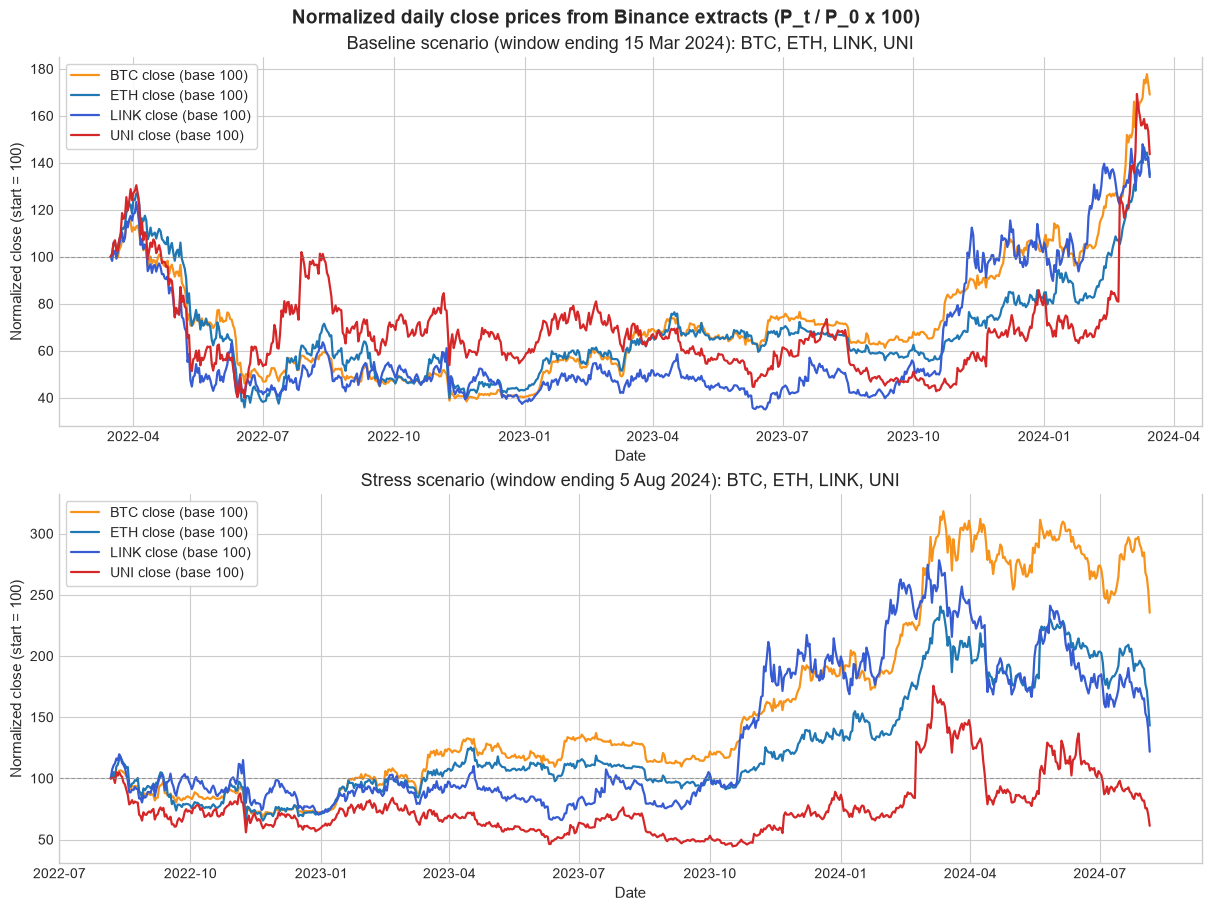

In [5]:
ASSET_COLORS = {
    "BTC": "#f7931a",
    "ETH": "#1f77b4",
    "LINK": "#375bd2",
    "UNI": "#d62728",
}


def normalize_close_to_base100(frame: pd.DataFrame) -> pd.Series:
    """Re-scale daily close prices so the first observation equals 100."""
    close = frame[CLOSE_COL]
    base_price = close.iloc[0]
    if base_price == 0:
        raise ValueError("Cannot normalize a series whose first close price is zero.")
    return (close / base_price) * 100.0


def plot_normalized_closes(
    ax: plt.Axes,
    asset_frames: dict[str, pd.DataFrame],
    title: str,
) -> None:
    """Plot BTC, ETH, LINK, and UNI closes on a common base-100 scale."""
    for asset, frame in asset_frames.items():
        normalized_close = normalize_close_to_base100(frame)
        ax.plot(
            frame.index,
            normalized_close,
            color=ASSET_COLORS[asset],
            linewidth=1.6,
            label=f"{asset} close (base 100)",
        )

    ax.axhline(100.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalized close (start = 100)")
    ax.legend(loc="upper left", framealpha=0.9)


fig, axes = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True)

plot_normalized_closes(
    axes[0],
    {
        "BTC": btc_baseline,
        "ETH": eth_baseline,
        "LINK": link_baseline,
        "UNI": uni_baseline,
    },
    title="Baseline scenario (window ending 15 Mar 2024): BTC, ETH, LINK, UNI",
)
plot_normalized_closes(
    axes[1],
    {
        "BTC": btc_stress,
        "ETH": eth_stress,
        "LINK": link_stress,
        "UNI": uni_stress,
    },
    title="Stress scenario (window ending 5 Aug 2024): BTC, ETH, LINK, UNI",
)

fig.suptitle(
    "Normalized daily close prices from Binance extracts (P_t / P_0 x 100)",
    fontsize=14,
    fontweight="bold",
)
plt.show()